Machine Learning  AutoML
الاسم: الحسين طوال


In [ ]:
!ls



Mall_Customers.csv  sample_data


In [ ]:
import pandas as pd

data = pd.read_csv("Mall_Customers.csv")
data.head()





,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


هذا الملف يحتوي على معلومات 200 زبون
مثل العمر، الدخل السنوي، ونقاط الإنفاق.

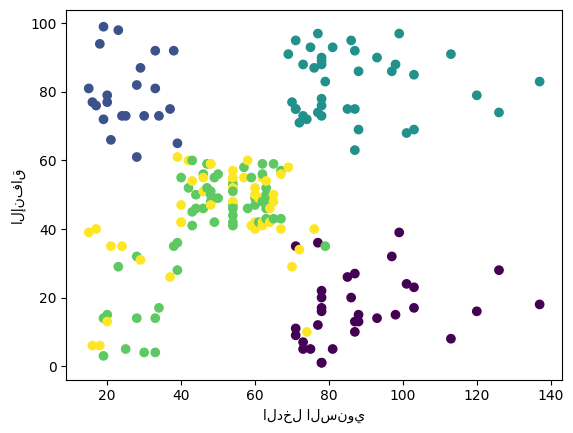

In [ ]:
X = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5)
clusters = kmeans.fit_predict(X_scaled)

data['Cluster'] = clusters

import matplotlib.pyplot as plt

plt.scatter(
    data['Annual Income (k$)'],
    data['Spending Score (1-100)'],
    c=data['Cluster']
)
plt.xlabel("الدخل السنوي")
plt.ylabel("الإنفاق")
plt.show()


نلاحظ أن الزبائن انقسموا إلى عدة مجموعات
كل مجموعة تمثل سلوك شراء مختلف.

مشروع 2: كشف الاحتيال على بطاقات الائتمان

الهدف: بناء نموذج تصنيف قادر على التمييز بين المعاملات العادية والاحتيالية.

- Class = 0 → عملية عادية
- Class = 1 → عملية احتيال

ملاحظة: البيانات غير متوازنة، أي أن عدد الاحتيالات قليل جدًا (<1%).


تحميل البيانات
سنقوم بقراءة ملف الذي يحتوي على جميع المعاملات البنكية


In [ ]:
import pandas as pd

data2 = pd.read_csv("creditcard.csv")
data2.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


نلاحظ ان البيانات تحتوي على العديد من الاعمدة الرقمية بالاضافة الى العمود الذي يمثل "class"

 استكشاف البيانات
نقوم بالتحقق من عدد الصفوف والأعمدة، والقيم المفقودة، وتوزيع الفئات.


In [ ]:
print(data2.shape)

print(data2.isnull().sum())

print(data2['Class'].value_counts())


(284807, 31)
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Class
0    284315
1       492
Name: count, dtype: int64


- معظم المعاملات عادية (Class=0)
- عدد الاحتيالات قليل جدًا (Class=1)

In [ ]:
X2 = data2.drop('Class', axis=1)
y2 = data2['Class']


نفصل العمود "Class" عن بقية البيانات ليكون المتغير الهدف y2.


In [ ]:
from sklearn.preprocessing import StandardScaler

X2_scaled = StandardScaler().fit_transform(X2)


نقوم بتوحيد جميع الأعمدة لأن النطاقات مختلفة، وهذا مهم لنماذج التصنيف.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X2_scaled, y2, test_size=0.3, stratify=y2, random_state=42
)


نقسم البيانات إلى 70% تدريب و30% اختبار.
- stratify=y2 للحفاظ على نسبة الاحتيالات في التدريب والاختبار.

نموذج Logistic Regression
سنبدأ بنموذج بسيط للتصنيف، يمكن لاحقًا استخدام Random Forest أو XGBoost لتحسين الأداء.
+Code

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

تقييم النموذج
نستخدم التقرير التصنيفي (Classification Report) ومصفوفة الالتباس (Confusion Matrix) لتقييم أداء النموذج.
+Code

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.60      0.70       148

    accuracy                           1.00     85443
   macro avg       0.92      0.80      0.85     85443
weighted avg       1.00      1.00      1.00     85443



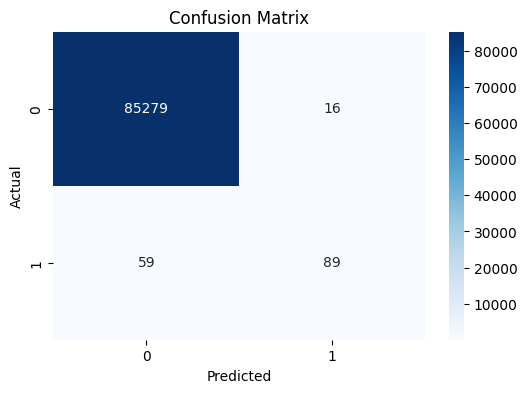

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


- Precision: نسبة العمليات المصنفة بشكل صحيح من بين الاحتيالات المكتشفة.
- Recall: نسبة الاحتيالات الحقيقية التي اكتشفها النموذج.
- F1-score: المتوسط بين Precision و Recall.

> أهم مقياس هنا هو Recall، لأنه إذا كان منخفضًا فإن الاحتيالات لن تُكتشف.
